In [1]:
import mg5qs_import as qs
import os
from pathlib import Path
import concurrent.futures
import pickle

## **Example: plot changes in components of transverse momenta $(pT_x, pT_y)$ caused by Pythia showering for $\tau^-$ and $W^+$.**

In [5]:
# create madgraph output directory structure
MG5_PATH = Path(os.getenv('MG5QS_MG5_PATH'))      # where is madgraph?
INPUT_PATH = Path(os.getenv('MG5QS_INPUT_PATH'))  # where is model's proc_card? 
qs.edit_card_spec(INPUT_PATH / 'proc_card_SM.dat')

#************************************************************
#*                        MadGraph 5                        *
#*                                                          *
#*                *                       *                 *
#*                  *        * *        *                   *
#*                    * * * * 5 * * * *                     *
#*                  *        * *        *                   *
#*                *                       *                 *
#*                                                          *
#*                                                          *
#*    The MadGraph Development Team - Please visit us at    *
#*    https://server06.fynu.ucl.ac.be/projects/madgraph     *
#*                                                          *
#************************************************************
#*                                                          *
#*               Command File for MadGraph 5                *
#*      

Text(value='set group_subprocesses Auto', layout=Layout(width='550px'))

Text(value='set ignore_six_quark_processes False', layout=Layout(width='550px'))

Text(value='set low_mem_multicore_nlo_generation False', layout=Layout(width='550px'))

Text(value='set complex_mass_scheme False', layout=Layout(width='550px'))

...

Text(value='define p = u u~ c c~ d d~ s s~ b b~ g', layout=Layout(width='550px'))

Text(value='generate p p > ta- vt~ SMHLOOP=0 NP<=1', layout=Layout(width='550px'))

Text(value='output SM', layout=Layout(width='550px'))

Button(description='Save', style=ButtonStyle())

Output()

In [6]:
output_name, FRAMEWORK_PATH = qs.run_MG5(qs.MG5_PATH, qs.INPUT_PATH, proc_card_name='proc_card_SM.dat')
output_name, FRAMEWORK_PATH

starting process...
done


('SM', PosixPath('/home/leo/MadStats/mg5qs/output/SM'))

In [7]:
qs.edit_card(FRAMEWORK_PATH)

#*********************************************************************
#                       MadGraph5_aMC@NLO                            *
#                                                                    *
#                     run_card.dat MadEvent                          *
#                                                                    *
#  This file is used to set the parameters of the run.               *
#                                                                    *
#  Some notation/conventions:                                        *
#                                                                    *
#   Lines starting with a '# ' are info or comments                  *
#                                                                    *
#   mind the format:   value    = variable     ! comment             *
#                                                                    *
#   To display more options, you can type the command:               *
#     

Text(value='tag_1     = run_tag ! name of the run', layout=Layout(width='550px'))

#*********************************************************************
# Number of events and rnd seed                                      *
# Warning: Do not generate more than 1M events in a single run       *
#*********************************************************************


Text(value='10000 = nevents ! Number of unweighted events requested', layout=Layout(width='550px'))

Text(value='0   = iseed   ! rnd seed (0=assigned automatically=default))', layout=Layout(width='550px'))

...

#


Text(value='systematics = systematics_program ! none, systematics [python], SysCalc [depreceted, C++]', layout…

Text(value="['--mur=0.5,1,2', '--muf=0.5,1,2', '--pdf=errorset'] = systematics_arguments ! see: https://cp3.ir…

Button(description='Save', style=ButtonStyle())

Output()

In [8]:
RUNS = 5
card = qs.ParamCard(FRAMEWORK_PATH / 'Cards' / 'param_card.dat')
for n in range(RUNS):
    qs.generate_LHE(card, FRAMEWORK_PATH)

In [9]:
FRAMEWORK_PATH = Path(os.getenv('MG5QS_INPUT_PATH')).parent/'output/SM/'
FRAMEWORK_PATH

PosixPath('/home/leo/MadStats/mg5qs/output/SM')

In [10]:
LHEs = qs.get_LHEs(FRAMEWORK_PATH)
LHEs

[PosixPath('/home/leo/MadStats/mg5qs/output/SM/Events/run_01/unweighted_events.lhe'),
 PosixPath('/home/leo/MadStats/mg5qs/output/SM/Events/run_05/unweighted_events.lhe'),
 PosixPath('/home/leo/MadStats/mg5qs/output/SM/Events/run_03/unweighted_events.lhe'),
 PosixPath('/home/leo/MadStats/mg5qs/output/SM/Events/run_04/unweighted_events.lhe'),
 PosixPath('/home/leo/MadStats/mg5qs/output/SM/Events/run_02/unweighted_events.lhe')]

### Generate Pythia showers capturing $\tau^-$ and $W^+$.

In [12]:
pythia.get_topics()

'LHE, PARENT, P_mu, CHAIN'

In [13]:
TAU = 15
W_BOSON = 24
qs.pythia_parallel([TAU,W_BOSON], FRAMEWORK_PATH, 'XY_compare', topics='P_mu CHAIN')


 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.311      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change:  8 Mar 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 04 Mar 2025 at 11:49:49    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

In [14]:
df = qs.unpickle('XY_compare')
df

,EVENT,ID,INDEX,PROCESS,STATUS,ISFINAL,ISCHARGED,CHAIN,CHAININDEX,CHAINLENGTH,px,py,pz,E
0,1,-24,5,2,-22,0,1,1,1,4,0.000000,0.000000,-69.474854,106.387969
1,1,-24,103,2,-44,0,1,1,2,4,2.219541,0.959009,-70.066667,106.802755
2,1,-24,329,2,-44,0,1,1,3,4,1.573261,0.529845,-70.201219,106.876619
3,1,-24,690,2,-62,0,1,1,4,4,0.697054,-1.767869,-70.230154,106.899628
4,1,15,931,2,-23,0,1,2,1,1,0.066469,-38.741970,-54.076285,66.545827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360901,10000,-24,16,2,-44,0,1,1,3,6,-16.860611,-8.039545,187.831519,203.697050
360902,10000,-24,25,2,-44,0,1,1,4,6,-15.663200,-8.508764,186.748533,202.621922
360903,10000,-24,154,2,-44,0,1,1,5,6,-15.396397,-8.631836,186.756635,202.614146
360904,10000,-24,173,2,-62,0,1,1,6,6,-14.721077,-9.027146,186.732723,202.559135


In [15]:
df['ID'].value_counts()

ID
-24    290024
 15     70610
-15       272
Name: count, dtype: int64

### Calculate $\Delta (pT_x,pT_y)$

In [16]:
max(df[df['ID']==-24]['CHAINLENGTH']),max(df[df['ID']==15]['CHAINLENGTH']),max(df[df['ID']==-15]['CHAINLENGTH'])

(14, 12, 1)

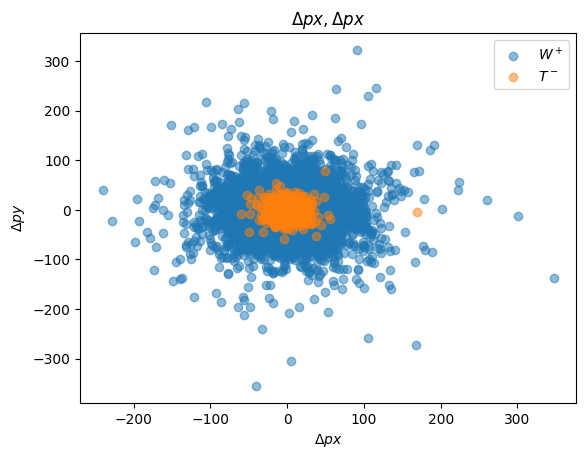

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_XY_deltas(df, pid):
    df_pid_first = df[(df['ID'] == pid) & (df['CHAININDEX'] == 1) & (df['CHAINLENGTH'] > 1)]
    df_pid_last = df[(df['ID'] == pid) & (df['CHAININDEX'] == df['CHAINLENGTH']) & (df['CHAINLENGTH'] > 1)]
    df_pid_first = df_pid_first.set_index('EVENT')
    df_pid_last = df_pid_last.set_index('EVENT')
    df_pid_last = df_pid_last.rename(columns={'px':'px_final', 'py':'py_final', 'pz':'pz_final', 'E': 'E_final'})
    df_pid = pd.concat([df_pid_first, df_pid_last], axis=1)
    return np.array(df_pid['px_final']-df_pid['px']), np.array(df_pid['py_final']-df_pid['py'])

px_W, py_W = get_XY_deltas(df, -24)
px_T, py_T = get_XY_deltas(df, 15)

plt.scatter(px_W, py_W, label='$W^+$', alpha=0.5)
plt.scatter(px_T, py_T, label='$T^-$', alpha=0.5)
plt.xlabel('$\\Delta px$')
plt.ylabel('$\\Delta py$')
plt.legend()
plt.title('$\\Delta px, \\Delta px$')
plt.show()

### Test alturnative return type (not Pandas)

In [27]:
ret = qs.run_pythia([TAU,W_BOSON], str(LHEs[0]), topics='P_mu CHAIN', dataframe=False)


 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.311      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change:  8 Mar 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 04 Mar 2025 at 11:56:51    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

In [28]:
ret

{'fvs': array([[ 0.00000000e+00,  0.00000000e+00, -3.93834609e+02,
          4.02113453e+02],
        [ 1.24620962e-02, -2.77608842e+00, -3.94940249e+02,
          4.03205949e+02],
        [-3.73620355e-01, -2.47727012e+00, -3.95035248e+02,
          4.03297227e+02],
        ...,
        [-1.10879153e+00, -4.02914515e+00, -2.68749307e+02,
          2.79746551e+02],
        [-7.84429333e-01, -4.61289885e+00, -2.69110281e+02,
          2.80101262e+02],
        [-1.31265894e+00,  3.07274683e+01, -2.01191006e+02,
          2.03535940e+02]]),
 'ivs': array([[    1,   -24,     5, ...,     1,     1,     4],
        [    1,   -24,    12, ...,     1,     2,     4],
        [    1,   -24,    83, ...,     1,     3,     4],
        ...,
        [10000,   -24,    38, ...,     1,     3,     4],
        [10000,   -24,   532, ...,     1,     4,     4],
        [10000,    15,   707, ...,     2,     1,     1]], dtype=int32),
 'n': 72276,
 'fields': 'EVENT,ID,INDEX,PROCESS,STATUS,ISFINAL,ISCHARGED,CHAIN,